In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


TASK 1 :Inspect & Handle Missing Values

In [6]:
print(f"Shape of the dataframe {df.shape}")
print("--------------------------------------")
print("Column types :")
print(df.dtypes)
print("--------------------------------------")

print("Missing null values :\n")
print(df.isnull().sum())
print("--------------------------------------")

print("Percentage of missing values")
count= df.isnull().sum()
print(count/len(df) * 100)

Shape of the dataframe (200, 6)
--------------------------------------
Column types :
order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object
--------------------------------------
Missing null values :

order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64
--------------------------------------
Percentage of missing values
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


TASK 2: Summarize & Visualize

In [7]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


Observations:


1.   In order_value, std > mean , outliers are present.
2.   mean > median - data is right skewed and if see the max value and min value of the order_value column. could see huge difference.
Delivery_days has less when compared to Order_value



Task 3 — Correlation Analysis

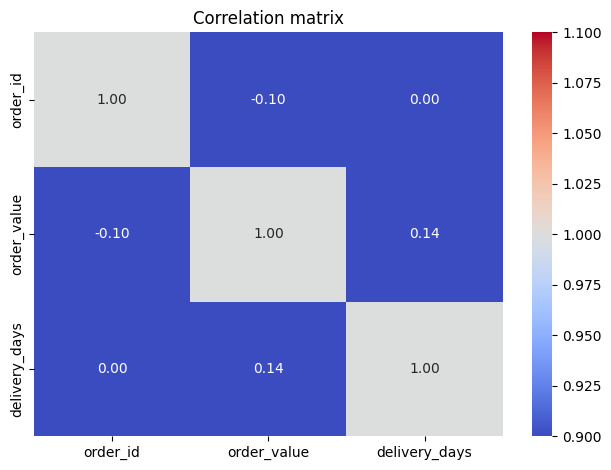

In [14]:
import seaborn as ss
import matplotlib.pyplot as plt

matrix = df.select_dtypes(include='number').corr()

ss.heatmap(matrix,
           vmin=1,vmax =1,
           annot=True,
           cmap="coolwarm",
           fmt =".2f")

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

between order_value and delivery days could see positive correlation